Cell 1 - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Cell 2 - Load Cleaned Datasets

In [2]:
products = pd.read_csv("../data/cleaned/products.csv")
inventory = pd.read_csv("../data/cleaned/inventory.csv")
sales_lines = pd.read_csv("../data/cleaned/sales_lines.csv")

Cell 3 - Dataset Overview

In [3]:
datasets = {
    "Products": products,
    "Inventory": inventory,
    "Sales Lines": sales_lines
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Products,30,25
1,Inventory,180,8
2,Sales Lines,130402,9


Cell 4 - Product Summary

In [4]:
print("PRODUCT SUMMARY")
print("-"*50)

print("Total Products :", products["product_id"].nunique())
print("Total Categories :", products["category"].nunique())
print("Total Brands :", products["brand"].nunique())
print("Total Machine Types :", products["machine_type"].nunique())

PRODUCT SUMMARY
--------------------------------------------------
Total Products : 30
Total Categories : 15
Total Brands : 6
Total Machine Types : 6


Cell 5 - Merge Product & Inventory Data

In [5]:
inventory_product = inventory.merge(
    products,
    on="product_id",
    how="left"
)

inventory_product.head()

,product_id,branch_id,opening_stock,reorder_level_x,safety_stock_x,max_stock,current_stock,warehouse_bin,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level_y,safety_stock_y,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month
0,P001,Del001,196,59,46,340,115928,C15,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
1,P001,Pun001,198,70,43,349,109389,D16,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
2,P001,Chn001,187,62,44,311,99373,A11,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
3,P001,Hyd001,226,71,65,417,108772,A10,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
4,P001,Kol001,263,94,58,475,103808,F03,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3


Cell 6 - Inventory Value Calculation

In [6]:
inventory_product["inventory_value"] = (
    inventory_product["current_stock"] *
    inventory_product["unit_cost"]
)

inventory_product[[
    "product_id",
    "product_name",
    "current_stock",
    "unit_cost",
    "inventory_value"
]].head()

,product_id,product_name,current_stock,unit_cost,inventory_value
0,P001,Hydraulic Pump Hp-300,115928,18950,2196835600
1,P001,Hydraulic Pump Hp-300,109389,18950,2072921550
2,P001,Hydraulic Pump Hp-300,99373,18950,1883118350
3,P001,Hydraulic Pump Hp-300,108772,18950,2061229400
4,P001,Hydraulic Pump Hp-300,103808,18950,1967161600


Cell 7 - Inventory Summary

In [7]:
print("INVENTORY SUMMARY")
print("-"*50)

print("Total Current Stock :", inventory_product["current_stock"].sum())

print("Average Current Stock :", round(
    inventory_product["current_stock"].mean(),2))

print("Total Inventory Value : ₹",
      round(inventory_product["inventory_value"].sum(),2))

print("Average Inventory Value : ₹",
      round(inventory_product["inventory_value"].mean(),2))

INVENTORY SUMMARY
--------------------------------------------------
Total Current Stock : 19303266
Average Current Stock : 107240.37
Total Inventory Value : ₹ 281292677410
Average Inventory Value : ₹ 1562737096.72


Cell 8 - Top 10 Products by Inventory Value

In [8]:
top_inventory = inventory_product.sort_values(
    by="inventory_value",
    ascending=False
).head(10)

top_inventory[[
    "product_name",
    "category",
    "current_stock",
    "inventory_value"
]]

,product_name,category,current_stock,inventory_value
86,Engine Block Eb-600,Engine,113851,10872770500
87,Engine Block Eb-600,Engine,110035,10508342500
85,Engine Block Eb-600,Engine,106048,10127584000
89,Engine Block Eb-600,Engine,105135,10040392500
84,Engine Block Eb-600,Engine,100967,9642348500
88,Engine Block Eb-600,Engine,96547,9220238500
80,Transmission Assembly Ta-800,Transmission,114302,7829687000
79,Transmission Assembly Ta-800,Transmission,113386,7766941000
78,Transmission Assembly Ta-800,Transmission,111321,7625488500
81,Transmission Assembly Ta-800,Transmission,111315,7625077500


Cell 9 - Visualization (Top Inventory Value)

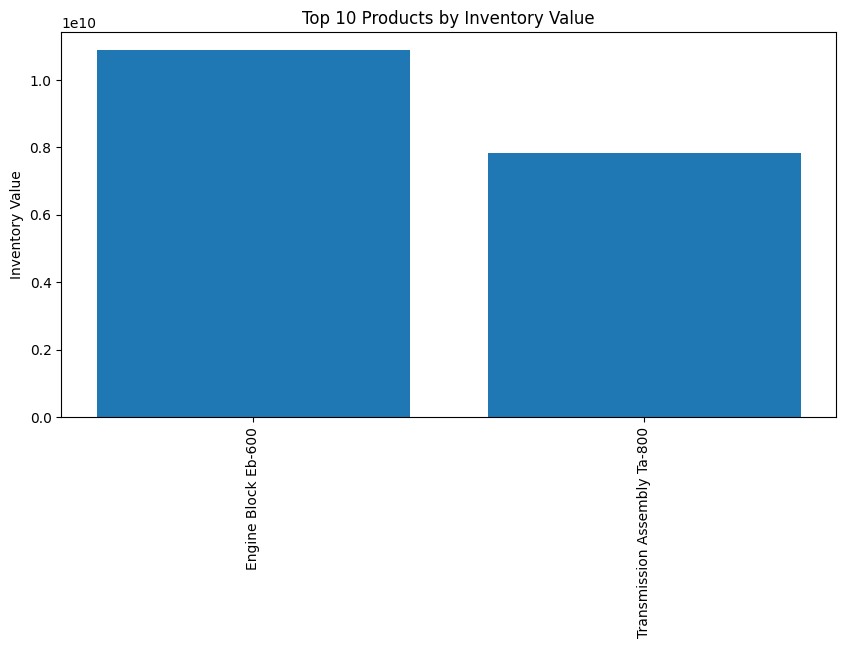

In [9]:
plt.figure(figsize=(10,5))

plt.bar(
    top_inventory["product_name"],
    top_inventory["inventory_value"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Products by Inventory Value")

plt.ylabel("Inventory Value")

plt.show()

Cell 10 - Bottom 10 Products by Inventory Value

In [10]:
bottom_inventory = inventory_product.sort_values(
    by="inventory_value"
).head(10)

bottom_inventory[[
    "product_name",
    "category",
    "current_stock",
    "inventory_value"
]]

,product_name,category,current_stock,inventory_value
154,Grease Cartridge Gc-5,Lubricants,101412,18254160
150,Grease Cartridge Gc-5,Lubricants,103678,18662040
155,Grease Cartridge Gc-5,Lubricants,103793,18682740
151,Grease Cartridge Gc-5,Lubricants,105190,18934200
153,Grease Cartridge Gc-5,Lubricants,108348,19502640
152,Grease Cartridge Gc-5,Lubricants,108895,19601100
158,O-Ring Set Or-50,Seals,97973,25472980
160,O-Ring Set Or-50,Seals,100477,26124020
159,O-Ring Set Or-50,Seals,104746,27233960
156,O-Ring Set Or-50,Seals,106775,27761500
